# Heritage Quinquennial (1995-2025): Shocks en Niveles y Logaritmos

Este notebook replica el enfoque quinquenal del análisis EFW, pero usando `heritage.csv` y la columna **Overall Score** del índice Heritage.

Reglas de muestra:
- Cobertura de datos: **1995-2025**.
- Frecuencia: años quinquenales (`1995, 2000, ..., 2025`).
- Shock estricto quinquenal: diferencia solo cuando existe par exacto `t-5`.

## 1) Configuración y rutas

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / '.git').exists() and (path / 'descriptive_analysis').exists():
            return path
    return start.resolve()


ROOT = find_repo_root(Path.cwd())
HERITAGE_PATH = ROOT / 'heritage.csv'
FIG_DIR = ROOT / 'outputs/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('HERITAGE_PATH:', HERITAGE_PATH)
print('Archivo existe:', HERITAGE_PATH.exists())

ROOT: /Users/gabrielsaco/Documents/GitHub/economic-freedom
HERITAGE_PATH: /Users/gabrielsaco/Documents/GitHub/economic-freedom/heritage.csv
Archivo existe: True


## 2) Lectura `heritage.csv`

In [4]:
# The CSV has a textual preamble before the actual header.

with open(HERITAGE_PATH, 'r', encoding='utf-8-sig') as f:
    raw_lines = f.readlines()

header_pattern = 'Country,Index Year,Overall Score'
header_idx = next((i for i, line in enumerate(raw_lines) if line.strip().startswith(header_pattern)), None)
assert header_idx is not None, 'No se encontró el header esperado en heritage.csv.'

heritage_raw = pd.read_csv(HERITAGE_PATH, skiprows=header_idx)

print('Header detectado en línea:', header_idx + 1)
print('Shape bruto:', heritage_raw.shape)
print('Columnas:')
print(heritage_raw.columns.tolist())
print('\nPrimeras filas:')
display(heritage_raw.head(8))

Header detectado en línea: 5
Shape bruto: (5704, 15)
Columnas:
['Country', 'Index Year', 'Overall Score', 'Property Rights', 'Government Integrity', 'Judicial Effectiveness', 'Tax Burden', 'Government Spending', 'Fiscal Health', 'Business Freedom', 'Labor Freedom', 'Monetary Freedom', 'Trade Freedom', 'Investment Freedom', 'Financial Freedom']

Primeras filas:


,Country,Index Year,Overall Score,Property Rights,Government Integrity,Judicial Effectiveness,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom
0,Afghanistan,2025,NaN,7.4,14.1,2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,2024,NaN,4.9,18.1,4.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,2023,NaN,5.8,5.4,12.7,NaN,NaN,NaN,34.6,45.1,NaN,NaN,NaN,NaN
3,Afghanistan,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,2021,53.0,30.3,29.1,25.7,91.1,76.1,99.9,53.9,59.9,80.8,68.6,10.0,10.0
5,Afghanistan,2020,54.7,48.3,24.8,30.0,91.4,79.2,99.9,54.7,61.6,81.0,66.0,10.0,10.0
6,Afghanistan,2019,51.5,19.6,25.2,29.6,91.7,80.3,99.3,49.2,60.4,76.7,66.0,10.0,10.0
7,Afghanistan,2018,51.3,17.9,26.2,28.2,91.8,79.3,98.3,53.0,57.3,77.8,66.0,10.0,10.0


## 3) Limpieza y diagnóstico de cobertura

In [5]:
heritage = heritage_raw.copy()

# Keep variables needed for this analysis
heritage = heritage[['Country', 'Index Year', 'Overall Score']].copy()
heritage = heritage.rename(
    columns={
        'Country': 'country',
        'Index Year': 'year',
        'Overall Score': 'overall_score',
    }
)

# Convert to numeric (N/A -> NaN)
heritage['year'] = pd.to_numeric(heritage['year'], errors='coerce')
heritage['overall_score'] = pd.to_numeric(heritage['overall_score'], errors='coerce')

heritage = heritage.dropna(subset=['country', 'year']).copy()
heritage['year'] = heritage['year'].astype(int)

# Restrict to requested coverage window
heritage = heritage[heritage['year'].between(1995, 2025)].copy()

print('Rows (1995-2025):', len(heritage))
print('Countries (any obs):', heritage['country'].nunique())
print('Year min/max:', int(heritage['year'].min()), int(heritage['year'].max()))
print('Non-null Overall Score:', int(heritage['overall_score'].notna().sum()))

coverage_annual = (
    heritage.groupby('year')
    .agg(
        n_countries=('country', 'nunique'),
        n_non_null_score=('overall_score', lambda s: s.notna().sum()),
    )
    .reset_index()
)

display(coverage_annual)

Rows (1995-2025): 5704
Countries (any obs): 186
Year min/max: 1995 2025
Non-null Overall Score: 5146


,year,n_countries,n_non_null_score
0,1995,183,101
1,1996,183,141
2,1997,183,149
3,1998,183,155
4,1999,183,160
5,2000,183,160
6,2001,183,155
7,2002,183,157
8,2003,183,157
9,2004,183,155


## 4) Panel quinquenal (1995-2025) y shocks estrictos

In [6]:
# Build quinquennial panel
quin = heritage[
    heritage['year'].between(1995, 2025)
    & (heritage['year'] % 5 == 0)
].copy()

quin = quin.sort_values(['country', 'year'])
quin = quin.drop_duplicates(['country', 'year'], keep='last')

# Strict level shock: score_t - score_{t-5}
quin['year_prev'] = quin.groupby('country')['year'].shift(1)
quin['score_prev'] = quin.groupby('country')['overall_score'].shift(1)
quin['shock_level_5y'] = np.where(
    (quin['year'] - quin['year_prev']) == 5,
    quin['overall_score'] - quin['score_prev'],
    np.nan,
)

# Strict log shock: ln(score_t) - ln(score_{t-5})
quin['log_score'] = np.where(quin['overall_score'] > 0, np.log(quin['overall_score']), np.nan)
quin['log_prev'] = quin.groupby('country')['log_score'].shift(1)
quin['shock_log_5y'] = np.where(
    (quin['year'] - quin['year_prev']) == 5,
    quin['log_score'] - quin['log_prev'],
    np.nan,
)

# Shocks displayed from 2000 onward due to 5-year lag from 1995 baseline
shocks_level = quin[quin['year'].between(2000, 2025) & quin['shock_level_5y'].notna()].copy()
shocks_log = quin[quin['year'].between(2000, 2025) & quin['shock_log_5y'].notna()].copy()

n_panel = quin['country'].nunique()
n_level = shocks_level['country'].nunique()
n_log = shocks_log['country'].nunique()
missing_level = sorted(set(quin['country']) - set(shocks_level['country']))
missing_log = sorted(set(quin['country']) - set(shocks_log['country']))

print('Quinquennial rows (1995-2025):', len(quin))
print('Countries in quin panel:', n_panel)
print('Strict level shocks rows (2000-2025):', len(shocks_level), '| countries:', n_level)
print('Strict log shocks rows (2000-2025):', len(shocks_log), '| countries:', n_log)
print('Countries without strict level shock:', len(missing_level))
print('Countries without strict log shock:', len(missing_log))

Quinquennial rows (1995-2025): 1288
Countries in quin panel: 186
Strict level shocks rows (2000-2025): 939 | countries: 182
Strict log shocks rows (2000-2025): 939 | countries: 182
Countries without strict level shock: 4
Countries without strict log shock: 4


## 5) Cobertura quinquenal por año (niveles y logs)

In [5]:
coverage_level = (
    shocks_level.groupby('year')
    .agg(
        n_countries=('country', 'nunique'),
        mean=('shock_level_5y', 'mean'),
        median=('shock_level_5y', 'median'),
        p10=('shock_level_5y', lambda s: s.quantile(0.10)),
        p90=('shock_level_5y', lambda s: s.quantile(0.90)),
    )
    .reset_index()
)

coverage_log = (
    shocks_log.groupby('year')
    .agg(
        n_countries=('country', 'nunique'),
        mean=('shock_log_5y', 'mean'),
        median=('shock_log_5y', 'median'),
        p10=('shock_log_5y', lambda s: s.quantile(0.10)),
        p90=('shock_log_5y', lambda s: s.quantile(0.90)),
    )
    .reset_index()
)

print('Coverage (levels):')
display(coverage_level.round(4))

print('Coverage (logs):')
display(coverage_log.round(5))

Coverage (levels):


,year,n_countries,mean,median,p10,p90
0,2000,101,2.2376,2.0,-4.10,8.00
1,2005,153,0.7242,0.9,-5.84,7.68
2,2010,155,0.8103,1.1,-5.22,6.14
3,2015,177,0.8655,0.4,-2.32,4.70
4,2020,177,1.2113,1.2,-3.64,5.94
5,2025,176,-1.7494,-1.6,-7.75,3.35


Coverage (logs):


,year,n_countries,mean,median,p10,p90
0,2000,101,0.04178,0.02899,-0.06211,0.16416
1,2005,153,0.01575,0.01348,-0.10553,0.14550
2,2010,155,-0.00324,0.01731,-0.09609,0.09645
3,2015,177,0.01911,0.00722,-0.03694,0.08931
4,2020,177,0.02605,0.02031,-0.06312,0.10850
5,2025,176,-0.03252,-0.02698,-0.13678,0.05329


## 6) Función de gráfico

In [6]:
def plot_fan_chart(
    shocks_df: pd.DataFrame,
    shock_col: str,
    y_label: str,
    out_stem: str,
    band_colors: list[tuple[float, str, float]],
    line_main: str,
    line_other: str,
    info_note: str,
):
    percentiles = np.round(np.arange(0.05, 1.0, 0.05), 2)
    q_by_year = (
        shocks_df.groupby('year')[shock_col]
        .quantile(percentiles)
        .unstack()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(27, 10), dpi=180)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Ribbons from outer to inner percentile bands
    for p, color, alpha in band_colors:
        ax.fill_between(
            q_by_year.index,
            q_by_year[p],
            q_by_year[1 - p],
            color=color,
            alpha=alpha,
            zorder=1,
            linewidth=0,
        )

    # Percentile trajectories (p5..p95)
    for p in percentiles:
        is_median = np.isclose(p, 0.50)
        ax.plot(
            q_by_year.index,
            q_by_year[p],
            color=line_main if is_median else line_other,
            linewidth=2.8 if is_median else (1.25 if p in [0.25, 0.75] else 0.9),
            alpha=0.98 if is_median else 0.88,
            zorder=3,
        )

    ax.axhline(0, color='#2e2e2e', linewidth=1.0, alpha=0.9, zorder=0)

    # Raw country shocks with horizontal jitter for readability
    plot_df = shocks_df.copy().sort_values(['year', 'country']).reset_index(drop=True)
    rng = np.random.default_rng(20260207)
    plot_df['x_plot'] = plot_df['year'] + rng.uniform(-1.45, 1.45, size=len(plot_df))

    ax.scatter(
        plot_df['x_plot'],
        plot_df[shock_col],
        s=13,
        color='#101010',
        alpha=0.43,
        linewidths=0,
        zorder=2,
    )

    for row in plot_df.itertuples(index=False):
        ax.text(
            row.x_plot + 0.03,
            getattr(row, shock_col) + 0.01,
            row.country,
            fontsize=4.3,
            color='#1d1d1d',
            alpha=0.74,
            ha='left',
            va='center',
            zorder=5,
            path_effects=[pe.withStroke(linewidth=1.1, foreground='white', alpha=0.9)],
        )

    ax.set_xlabel('Ano del shock (t). Cobertura quinquenal de datos: 1995-2025 (shocks mostrados 2000-2025)', fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_xlim(1998, 2027)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.tick_params(axis='both', labelsize=10)

    ax.grid(axis='y', linestyle='--', linewidth=0.75, alpha=0.35, color='#7f7f7f')
    ax.grid(axis='x', linestyle=':', linewidth=0.55, alpha=0.28, color='#7f7f7f')

    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')

    legend_handles = [
        Line2D([0], [0], color=line_main, lw=2.8, label='Mediana (p50) de shocks estrictos'),
        Line2D([0], [0], color=line_other, lw=1.25, label='Trayectorias percentiles p5-p95 (cada 5 puntos)'),
        Patch(facecolor=band_colors[3][1], alpha=band_colors[3][2], label='Bandas percentiles simetricas (p40-p60 ... p5-p95)'),
        Line2D([0], [0], marker='o', color='#101010', lw=0, markersize=6, alpha=0.5, label='Shock estricto por pais-ano (5 anos)'),
    ]
    ax.legend(handles=legend_handles, loc='upper right', frameon=False, fontsize=10)

    ax.text(
        0.005,
        0.01,
        info_note,
        transform=ax.transAxes,
        fontsize=9.2,
        color='#343434',
        ha='left',
        va='bottom',
    )

    plt.tight_layout()

    out_png = FIG_DIR / f'{out_stem}.png'
    out_pdf = FIG_DIR / f'{out_stem}.pdf'
    out_svg = FIG_DIR / f'{out_stem}.svg'

    fig.savefig(out_png, dpi=600, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    fig.savefig(out_svg, bbox_inches='tight')
    plt.show()

    print('Figuras guardadas en:')
    print('-', out_png)
    print('-', out_pdf)
    print('-', out_svg)

IMPORTANTE: El “año del índice” no es exactamente “datos del mismo año”. Por ejemplo, el Índice 2025 se construye mayormente con información de 2H-2023 a 1H-2024 (corte ~30/jun/2024).

## 8) Figuras finales Heritage (muestra 1995-2025)

### 8.1) Figura en niveles (Overall Score)

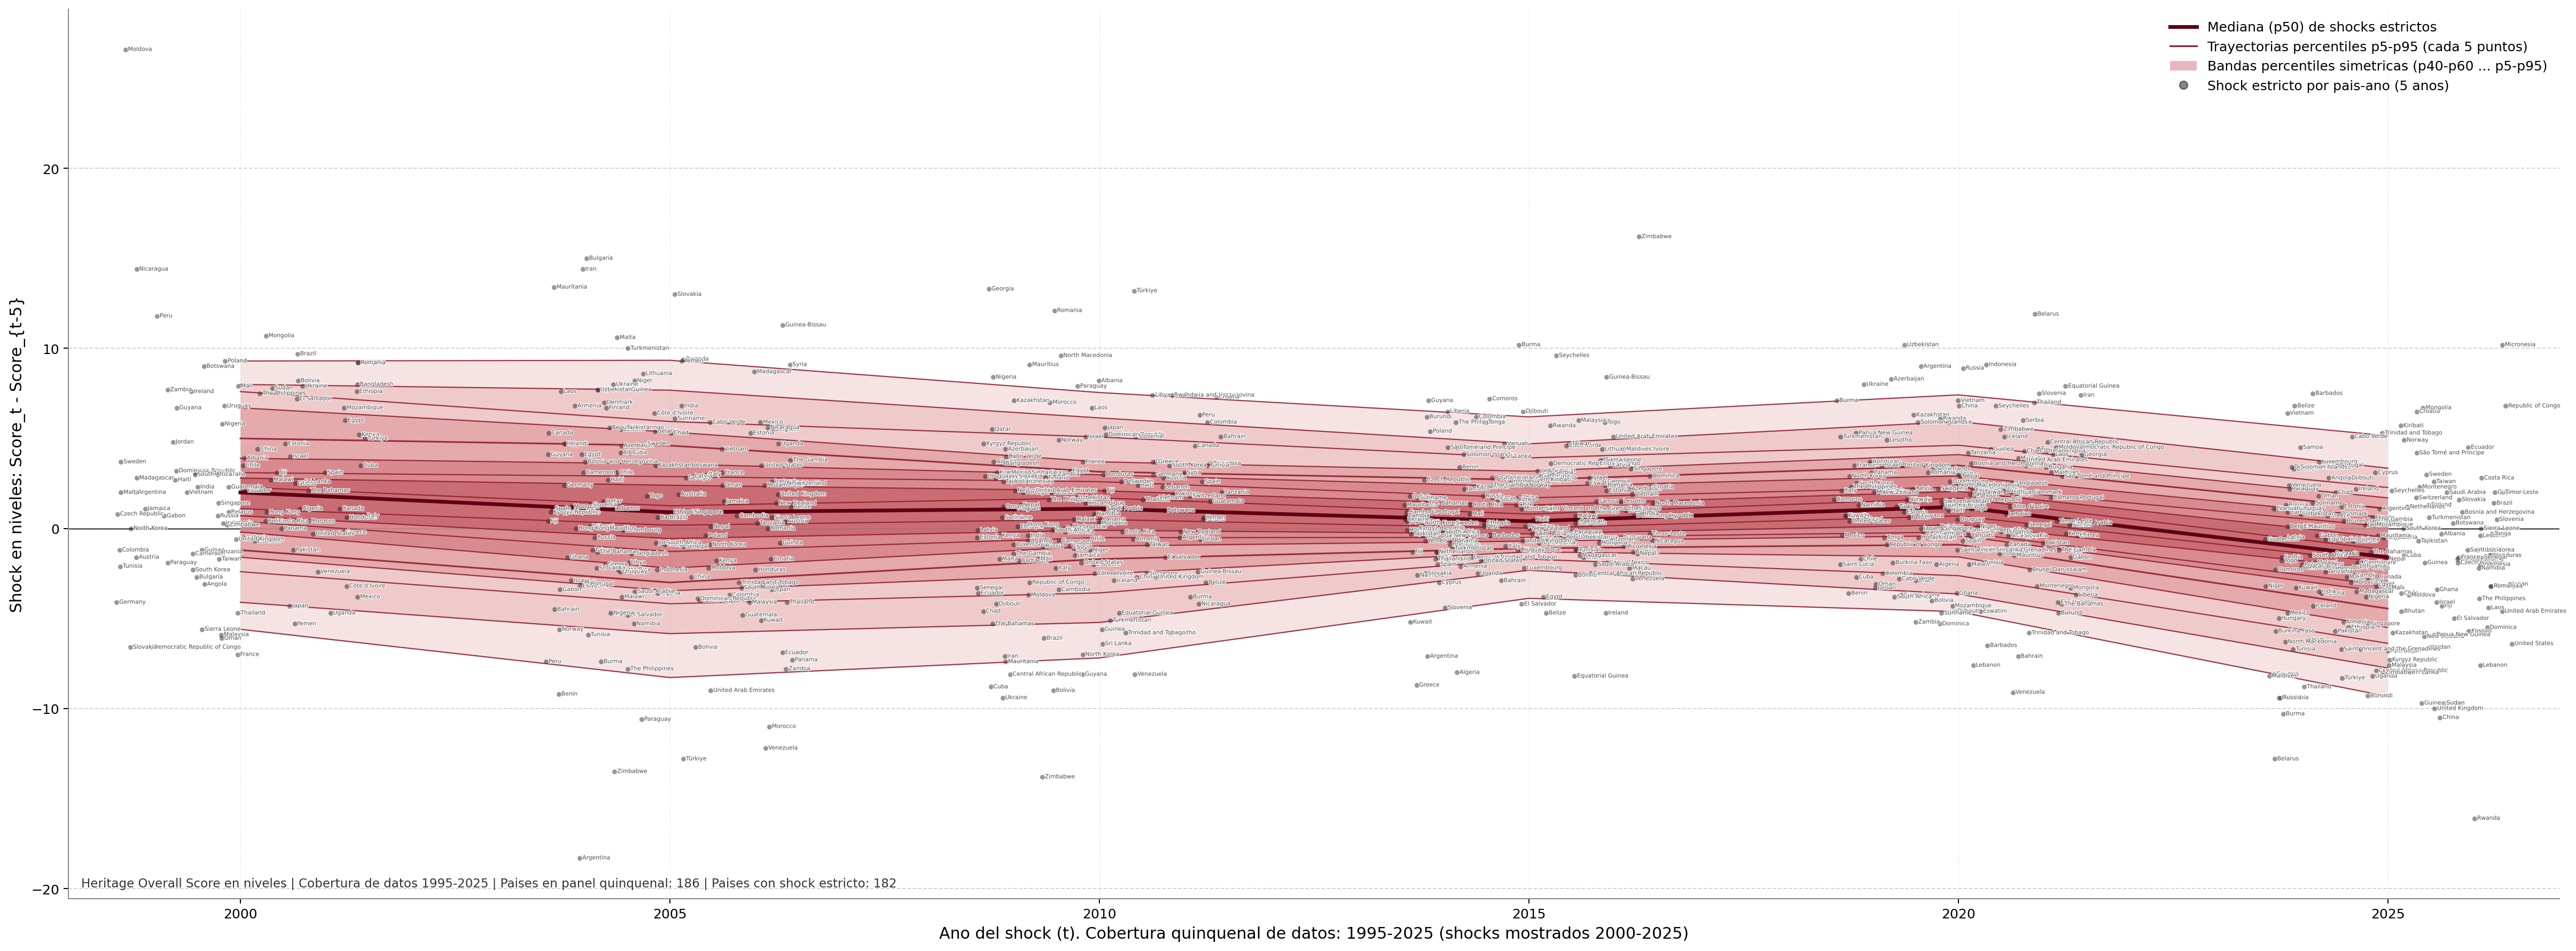

Figuras guardadas en:
- /Users/gabrielsaco/Documents/GitHub/economic-freedom/outputs/figures/heritage_quinquennial_shocks_levels_2000_2025_publication.png
- /Users/gabrielsaco/Documents/GitHub/economic-freedom/outputs/figures/heritage_quinquennial_shocks_levels_2000_2025_publication.pdf
- /Users/gabrielsaco/Documents/GitHub/economic-freedom/outputs/figures/heritage_quinquennial_shocks_levels_2000_2025_publication.svg


In [7]:
level_bands = [
    (0.05, '#f3d9da', 0.70),
    (0.10, '#eababc', 0.62),
    (0.20, '#dd8f93', 0.54),
    (0.30, '#ca666d', 0.46),
    (0.40, '#b63f49', 0.40),
]

level_note = (
    f"Heritage Overall Score en niveles | Cobertura de datos 1995-2025 | "
    f"Paises en panel quinquenal: {n_panel} | "
    f"Paises con shock estricto: {shocks_level['country'].nunique()}"
)

plot_fan_chart(
    shocks_df=shocks_level,
    shock_col='shock_level_5y',
    y_label='Shock en niveles: Score_t - Score_{t-5}',
    out_stem='heritage_quinquennial_shocks_levels_2000_2025_publication',
    band_colors=level_bands,
    line_main='#5c0011',
    line_other='#8f1d2f',
    info_note=level_note,
)

### 8.2) Figura en logaritmos (Overall Score)

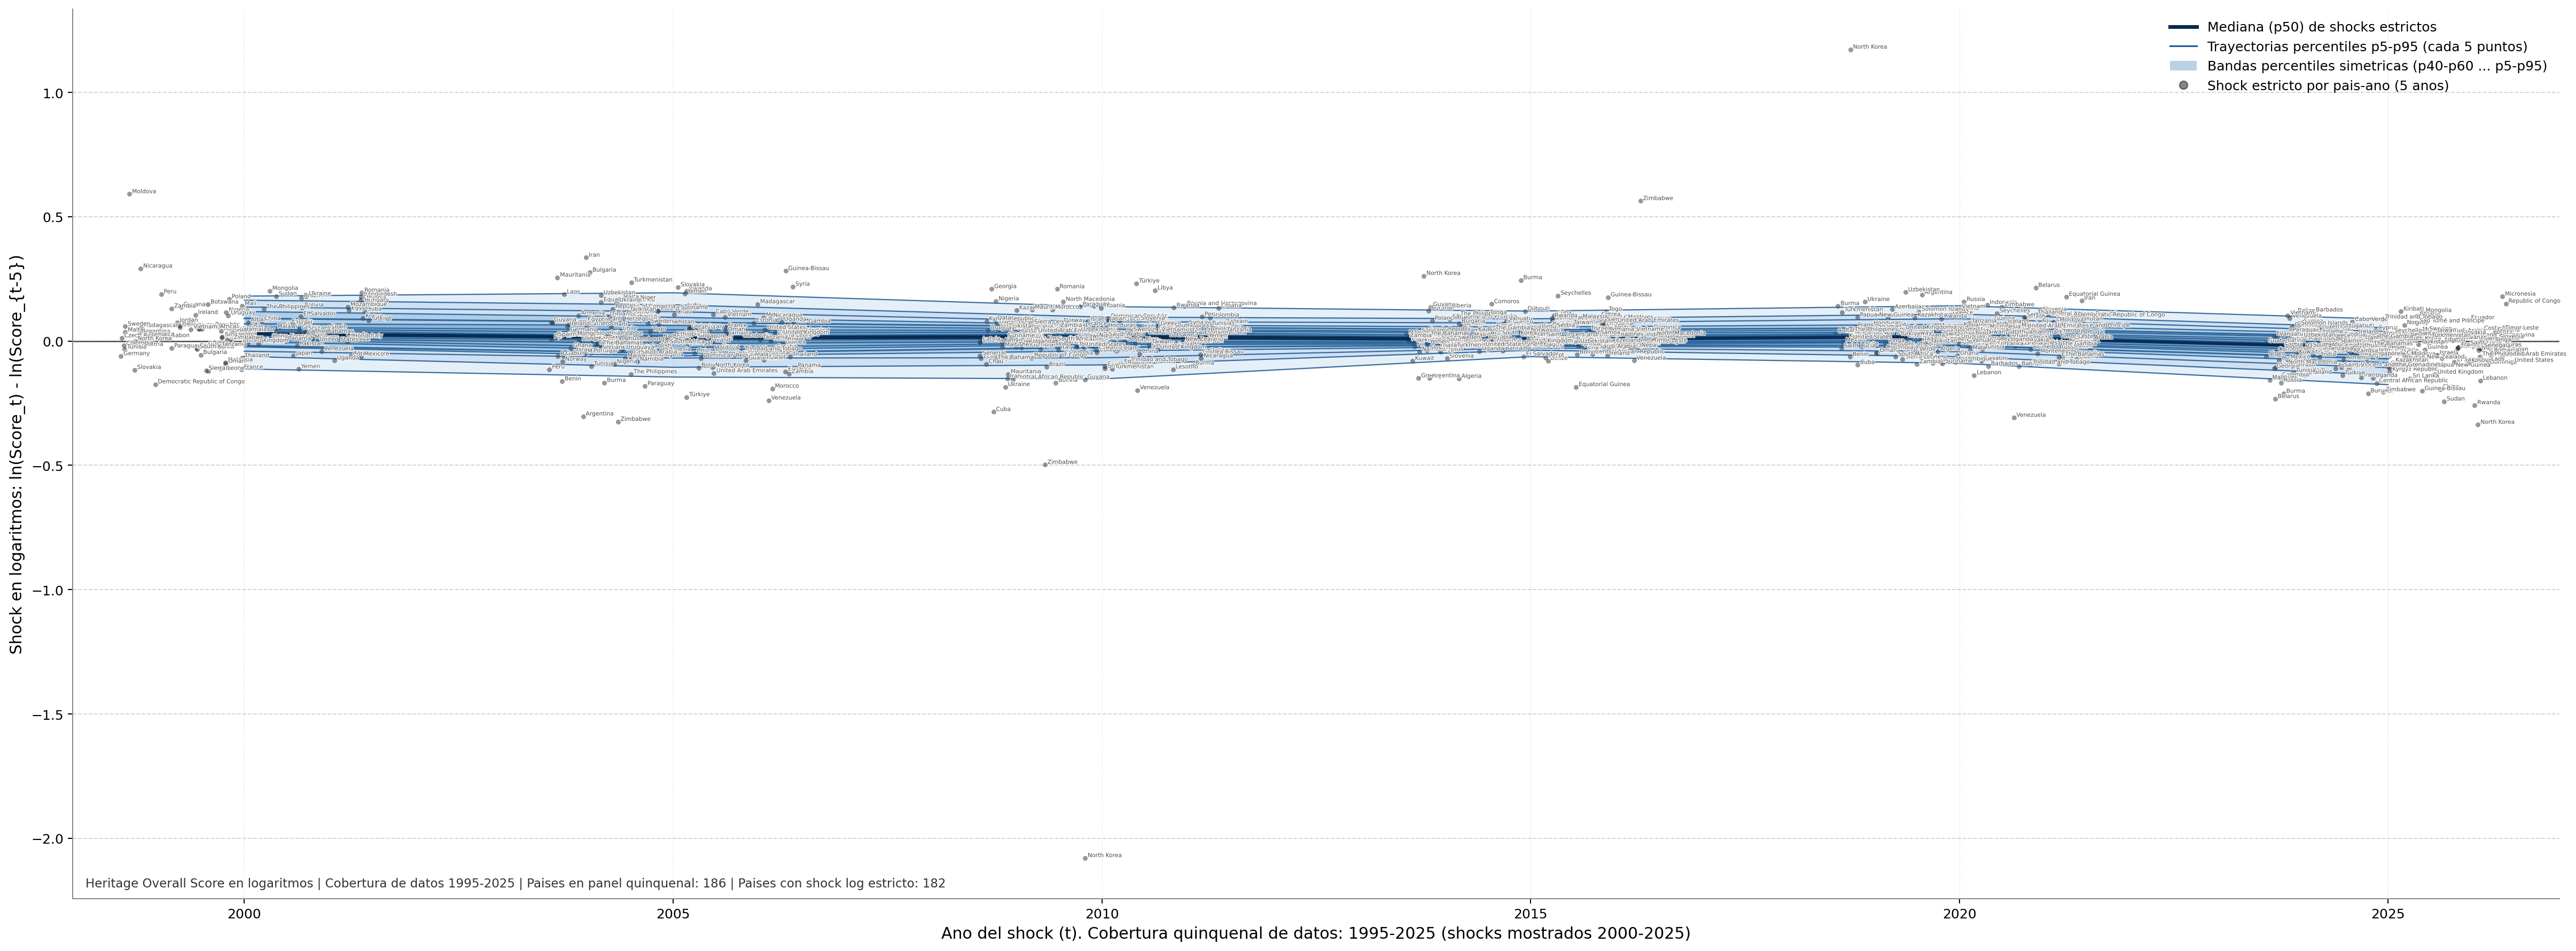

Figuras guardadas en:
- /Users/gabrielsaco/Documents/GitHub/economic-freedom/outputs/figures/heritage_quinquennial_shocks_logs_2000_2025_publication.png
- /Users/gabrielsaco/Documents/GitHub/economic-freedom/outputs/figures/heritage_quinquennial_shocks_logs_2000_2025_publication.pdf
- /Users/gabrielsaco/Documents/GitHub/economic-freedom/outputs/figures/heritage_quinquennial_shocks_logs_2000_2025_publication.svg


In [8]:
log_bands = [
    (0.05, '#dbe9f6', 0.72),
    (0.10, '#c2d9ef', 0.64),
    (0.20, '#98bfe0', 0.56),
    (0.30, '#6f9ec8', 0.48),
    (0.40, '#477eaf', 0.40),
]

log_note = (
    f"Heritage Overall Score en logaritmos | Cobertura de datos 1995-2025 | "
    f"Paises en panel quinquenal: {n_panel} | "
    f"Paises con shock log estricto: {shocks_log['country'].nunique()}"
)

plot_fan_chart(
    shocks_df=shocks_log,
    shock_col='shock_log_5y',
    y_label='Shock en logaritmos: ln(Score_t) - ln(Score_{t-5})',
    out_stem='heritage_quinquennial_shocks_logs_2000_2025_publication',
    band_colors=log_bands,
    line_main='#082a4f',
    line_other='#1f5b93',
    info_note=log_note,
)

## 9) Resumen para reporte

In [9]:
summary = pd.DataFrame([
    {
        'sample': 'heritage_quinquennial_1995_2025',
        'countries_panel': n_panel,
        'countries_level_shock': shocks_level['country'].nunique(),
        'countries_log_shock': shocks_log['country'].nunique(),
        'obs_level_shock': len(shocks_level),
        'obs_log_shock': len(shocks_log),
        'shock_year_min': int(min(shocks_level['year'].min(), shocks_log['year'].min())),
        'shock_year_max': int(max(shocks_level['year'].max(), shocks_log['year'].max())),
    }
])

display(summary)

,sample,countries_panel,countries_level_shock,countries_log_shock,obs_level_shock,obs_log_shock,shock_year_min,shock_year_max
0,heritage_quinquennial_1995_2025,186,182,182,939,939,2000,2025
